# 02 — Query a grid, dimensionally

**Access pattern: REST griddap.** One dataset, addressed by index expression, returned
in whatever format you negotiate.

ERDDAP is the reference implementation and it fronts dozens of NOAA and NASA datasets.
The pattern is common to OPeNDAP servers generally, and the same three or four traps
apply to most of them.

In [1]:
import sys
from pathlib import Path

# notebooks/ holds _fetch.py and _sources.py; src/ holds the project's own helpers.
for p in (Path.cwd(), Path.cwd() / ".." / "src"):
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p.resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import _fetch
import _sources as S

# A real requests.Session, with a disk cache. Everything you use below -- .get,
# .text, .content, .json, .status_code, .raise_for_status, params= -- is
# ordinary `requests`. The cache is invisible at the call site.
http = _fetch.session()

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

_fetch.OFFLINE and print("offline mode: serving prefetched responses")

False

## 1. What you should get

| | |
|---|---|
| Endpoint | `coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41` |
| Variable | `analysed_sst` — daily analysed SST, 0.045°, 2002–present |
| Dimensions | `time`, `latitude`, `longitude` — always in that order, for every griddap |
| As netCDF | 30 × 23 × 23, 134,020 bytes |

The dimension order is a **property of the server, not of your query**, and it is the
single most common reason a griddap query returns an error: the brackets have to
follow the server's axis order, and you cannot tell from the URL which order that is.
You have to ask.

In [2]:
# The server tells you its own shape. Always ask before you index.
info = http.get(f"{S.ERDDAP}.das").text
for line in info.splitlines():
    if any(k in line for k in ("dimensions:", "time {", "latitude {", "longitude {")):
        print("   ", line.strip())

    time {
    latitude {
    longitude {


## 2. The index expression

A griddap query names the variable, then brackets each dimension in server order:

```
<endpoint>.<format>?<variable>[<time>][<lat>][<lon>]
```

Each bracket is `[start:(stop)]` in the dimension's own units — a real timestamp for
`time`, decimal degrees for the spatial ones. A range whose start equals its stop is a
*degenerate range*, which is how you ask for exactly one cell.

In [3]:
lat0, lat1, lon0, lon1 = S.SST_BOX
parts = {
    "endpoint + format": f"{S.ERDDAP}.csv",
    "variable":          "analysed_sst",
    "time":              "[(2019-09-01T00:00:00Z):(2019-09-30T00:00:00Z)]",
    "latitude":          f"[({lat0}):({lat1})]",
    "longitude":         f"[({lon0}):({lon1})]",
}
for k, v in parts.items():
    print(f"  {k:18} {v}")

print()
print("  concatenated:")
print("   ", S.sst_csv())

  endpoint + format  https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41.csv
  variable           analysed_sst
  time               [(2019-09-01T00:00:00Z):(2019-09-30T00:00:00Z)]
  latitude           [(36.6):(36.82)]
  longitude          [(-122.2):(-121.98)]

  concatenated:
    https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41.csv?analysed_sst[(2019-09-01T00:00:00Z):(2019-09-30T00:00:00Z)][(36.6):(36.82)][(-122.2):(-121.98)]


### ⚠️ Trap — the axis order is not the order you expect

Reversing the spatial brackets does **not** error. It returns a plausible field, because
the numbers still land inside the dataset's latitude range. It is simply the wrong
answer, transposed.

This is the dangerous class of error: the server was asked a well-formed question, and
answered it correctly. The only defence is to check the axis order against the `.das`
metadata *before* trusting a spatial result, and to sanity-check that the latitude range
you got back is the one you asked for.

In [4]:
# Prove the ordering matters by checking what comes back, not by trusting the URL.
txt = http.get(S.sst_csv()).text
import io
d = pd.read_csv(io.StringIO(txt), skiprows=[1])
print("  latitude  range returned:", d.latitude.min(), "..", d.latitude.max())
print("  longitude range returned:", d.longitude.min(), "..", d.longitude.max())
print("  latitude  range asked for:", lat0, "..", lat1)
print("  longitude range asked for:", lon0, "..", lon1)
print()
print("  -> matches. Had the brackets been swapped, latitude and longitude above")
print("     would be reversed while still looking entirely reasonable.")

  latitude  range returned: 36.6 .. 36.82
  longitude range returned: -122.2 .. -121.98
  latitude  range asked for: 36.6 .. 36.82
  longitude range asked for: -122.2 .. -121.98

  -> matches. Had the brackets been swapped, latitude and longitude above
     would be reversed while still looking entirely reasonable.


## 3. Format negotiation

The extension before the `?` is the format. Same query, different serialisation:

| extension | you get | size for this month |
|---|---|---|
| `.csv` | flat table, **two** header rows | 690,813 B |
| `.nc` | CF-1.6 netCDF, labelled dimensions | 134,020 B |
| `.json` | nested objects | larger |
| `.html` | a table you can look at in a browser | — |

`.nc` is smaller *and* self-describing: units, axis order and coordinates travel with
the data, so `xarray` does not have to be told what the columns mean. For anything past
exploration, ask for `.nc` first.

In [5]:
import xarray as xr

nc = http.get(S.sst_nc())
p = Path.cwd() / "_sst_month.nc"
p.write_bytes(nc.content)
ds = xr.open_dataset(p)

print("  csv:", f"{len(http.get(S.sst_csv()).content):,} bytes")
print("  nc :", f"{len(nc.content):,} bytes")
print()
print("  and the netCDF answers questions the CSV cannot:")
print("    units       :", ds[S.SST_VAR].attrs.get("units"))
print("    conventions :", ds.attrs.get("Conventions"))
print("    creator     :", ds.attrs.get("creator_name"))

  csv: 690,813 bytes
  nc : 134,020 bytes

  and the netCDF answers questions the CSV cannot:
    units       : degree_C
    conventions : CF-1.6, COARDS, ACDD-1.3
    creator     : JPL MUR SST project


### ⚠️ Trap — coordinates come back as `float32`

ERDDAP stores its grid in single precision. A box you requested as `36.60` to `36.82`
can come back with a `latitude.min()` of `36.599998` and a `latitude.max()` of
`36.820002` — outside the box you asked for, by a few millionths of a degree.

The result is a spatial filter that mysteriously excludes the edge of your own
selection. Use a tolerance rather than exact comparison:

```python
assert lat0 - 1e-3 <= ds.latitude.min() and ds.latitude.max() <= lat1 + 1e-3
```

In [6]:
lat_min, lat_max = float(ds.latitude.min()), float(ds.latitude.max())
print(f"  requested : {lat0} .. {lat1}")
print(f"  returned  : {lat_min!r} .. {lat_max!r}")
print(f"  dtype     : {ds.latitude.dtype}")
print()
print("  exact comparison passes? ", lat0 <= lat_min and lat_max <= lat1)
print("  with a 1e-3 tolerance?    ", lat0 - 1e-3 <= lat_min and lat_max <= lat1 + 1e-3)
print()
print("  The fill value is the other half of this trap, and the two are not")
print("  interchangeable:")
sst = ds[S.SST_VAR]
print(f"    dtype                  : {sst.dtype}")
print(f"    NaN cells              : {int(sst.isnull().sum())}")
print(f"    cells <= -1 C (fill)   : {int((sst <= -1.0).sum())}")
print(f"    overall min            : {float(sst.min()):.2f}")
print()
print("  A NaN fill is skipped automatically by every reduction. A -999.0 fill is NOT:")
import numpy as _np
with_fill    = float(sst.mean(dim="time").mean())
without_fill = float(sst.where(sst > -1.0).mean(dim="time").mean())
print(f"    mean including fill   : {with_fill:.4f}")
print(f"    mean excluding fill   : {without_fill:.4f}")
print(f"    difference            : {with_fill - without_fill:.4f} C")
print()
print("  So 'is my field physical?' is a check worth automating, not eyeballing.")

  requested : 36.6 .. 36.82
  returned  : 36.599998474121094 .. 36.81999969482422
  dtype     : float32

  exact comparison passes?  False
  with a 1e-3 tolerance?     True

  The fill value is the other half of this trap, and the two are not
  interchangeable:
    dtype                  : float64
    NaN cells              : 0
    cells <= -1 C (fill)   : 0
    overall min            : 14.37

  A NaN fill is skipped automatically by every reduction. A -999.0 fill is NOT:
    mean including fill   : 15.5837
    mean excluding fill   : 15.5837
    difference            : 0.0000 C

  So 'is my field physical?' is a check worth automating, not eyeballing.


### ⚠️ Trap — `itemsPerLargePage` silently returns nothing

ERDDAP pages large CSV responses. Ask for page 2 without asking for page 1 and you get
an **empty response with HTTP 200** — not an error, not a warning, just nothing. If you
are paging a large dataset and a page comes back empty, this is almost always why.

## 4. The field, and what it is showing you

Now the reason we came. A month of SST over the bay, as a map.

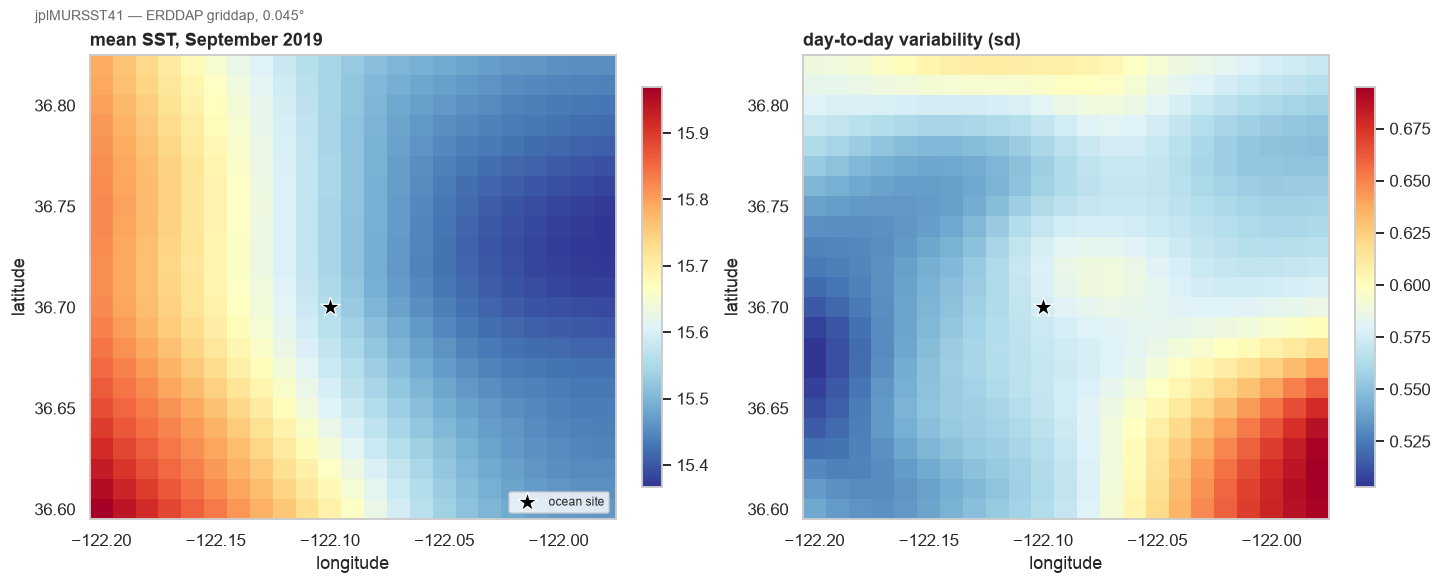

In [7]:
mean_field = ds[S.SST_VAR].where(ds[S.SST_VAR] > -1.0).mean(dim="time")
spread = ds[S.SST_VAR].where(ds[S.SST_VAR] > -1.0).std(dim="time")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), constrained_layout=True)

for ax, field, title in [
    (axes[0], mean_field, "mean SST, September 2019"),
    (axes[1], spread,    "day-to-day variability (sd)"),
]:
    im = ax.pcolormesh(field.longitude, field.latitude, field.values,
                       cmap="RdYlBu_r", shading="nearest")
    ax.scatter([S.SITE_LON], [S.SITE_LAT], marker="*", s=180, c="black",
               edgecolors="white", linewidths=0.8, zorder=3, label="ocean site")
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
    fig.colorbar(im, ax=ax, shrink=0.86)

axes[0].legend(loc="lower right", fontsize=8)
plt.suptitle("jplMURSST41 — ERDDAP griddap, 0.045°", x=0.02, ha="left",
             fontsize=9, color="#666")
plt.show()

In [8]:
# The physical reading. Scalar reductions on a 2-D DataArray need numpy -- xarray
# wants an explicit `dim` for anything but a 1-D array.
vals  = mean_field.values
lats  = mean_field.latitude.values
lons  = mean_field.longitude.values
cold, warm = float(vals.min()), float(vals.max())
ci, cj = np.unravel_index(int(vals.argmin()), vals.shape)
wi, wj = np.unravel_index(int(vals.argmax()), vals.shape)

print(f"  mean field spans {cold:.2f} .. {warm:.2f} C   (range {warm - cold:.2f} C)")
print(f"  coldest cell: lat {lats[ci]:.2f}  lon {lons[cj]:.2f}   (NE, inshore)")
print(f"  warmest cell: lat {lats[wi]:.2f}  lon {lons[wj]:.2f}   (SW, offshore)")
print()
print("  It is a smooth, monotonic SW -> NE gradient: offshore water is warmer, and")
print("  the water at the northern, inshore corner of the bay is coldest. That is the")
print("  upwelling centre, and it sits at the mouth of Monterey Bay. Northerly wind")
print("  drags surface water away from the coast and cold water rises to replace it,")
print("  so the coldest water is the closest-to-land water at the northern end.")
print()
print(f"  Note the gradient is only {warm - cold:.2f} C. That is small in absolute terms")
print("  and easy to dismiss -- and it is the entire spatial signal in this box.")
print("  Whether that matters depends on the question, which is the next notebook.")

  mean field spans 15.37 .. 15.97 C   (range 0.60 C)
  coldest cell: lat 36.73  lon -121.98   (NE, inshore)
  warmest cell: lat 36.60  lon -122.20   (SW, offshore)

  It is a smooth, monotonic SW -> NE gradient: offshore water is warmer, and
  the water at the northern, inshore corner of the bay is coldest. That is the
  upwelling centre, and it sits at the mouth of Monterey Bay. Northerly wind
  drags surface water away from the coast and cold water rises to replace it,
  so the coldest water is the closest-to-land water at the northern end.

  Note the gradient is only 0.60 C. That is small in absolute terms
  and easy to dismiss -- and it is the entire spatial signal in this box.
  Whether that matters depends on the question, which is the next notebook.


In [9]:
_fetch.expect("netCDF bytes", len(nc.content), 134020)
_fetch.expect("time steps", int(ds.sizes["time"]), 30)
_fetch.expect("latitude points", int(ds.sizes["latitude"]), 23)
_fetch.expect("longitude points", int(ds.sizes["longitude"]), 23)
_fetch.expect_range("mean SST", float(mean_field.values.mean()), 15.0, 17.0)
_fetch.expect_range("field range", warm - cold, 0.5, 8.0)
print()
print("  A field with a range near zero would mean the fill values leaked in.")
print("  A mean outside 12-20 C would mean the wrong box or the wrong month.")

  ok  netCDF bytes: got 134020, expected 134020
  ok  time steps: got 30, expected 30
  ok  latitude points: got 23, expected 23
  ok  longitude points: got 23, expected 23
  ok  mean SST: 15.583658097038436 in [15.0, 17.0]
  ok  field range: 0.6015666666666668 in [0.5, 8.0]

  A field with a range near zero would mean the fill values leaked in.
  A mean outside 12-20 C would mean the wrong box or the wrong month.
